(244, 691, 20)


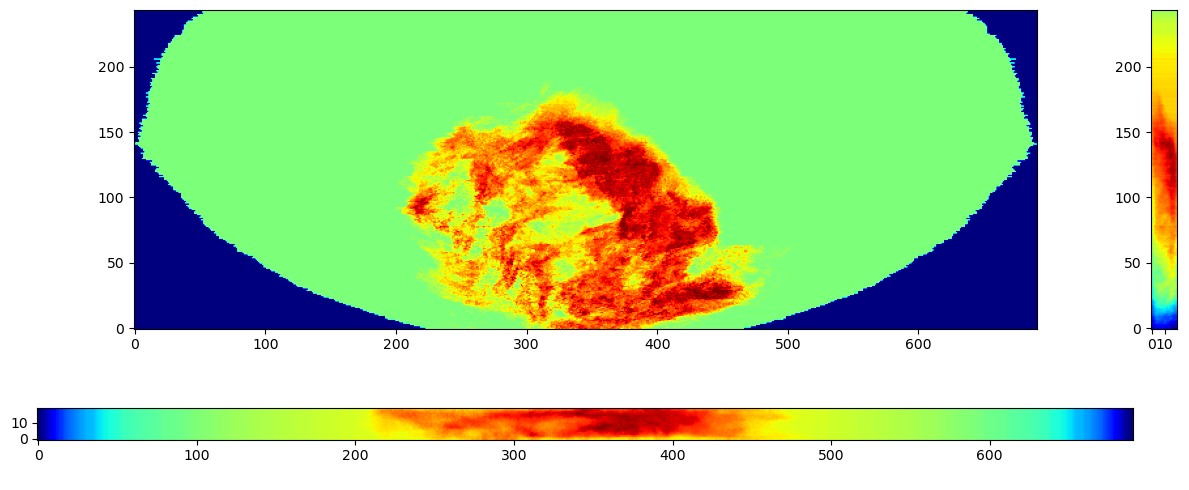

In [26]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# path = Path("/Users/arstanbek/Projects/fibrosis/BiTis/data/3D")
# path = Path("/home/arstan/Projects/Fibrosis/BiTis/data/3D")
path = Path("/Users/arstanbek/Projects/fibrosis/FibrosisSimulation/data")
hearts_list = ["Zep1", "Zep3", "Zep4",
               "Zep6", "Zep7", "Zep8",
               "Zep9", "Zep10", "Zep11"]

heart = hearts_list[4]
slab_or = np.load(path.joinpath(heart, "slab.npy")).astype(np.float32)
slab_or = slab_or[::-1]
print(slab_or.shape)


fig, axs = plt.subplots(2, 2, figsize=(12, 5),
                        width_ratios=[1, slab_or.shape[2]/slab_or.shape[1]],
                        height_ratios=[1, slab_or.shape[0]/slab_or.shape[1]])

axs[0, 0].imshow(slab_or.sum(axis=2), cmap="jet", origin='lower')
axs[0, 1].imshow(slab_or.sum(axis=1), cmap="jet", origin='lower')
axs[1, 0].imshow(slab_or.sum(axis=0).T, cmap="jet", origin='lower')
axs[1, 1].axis("off")
plt.tight_layout()
plt.show()

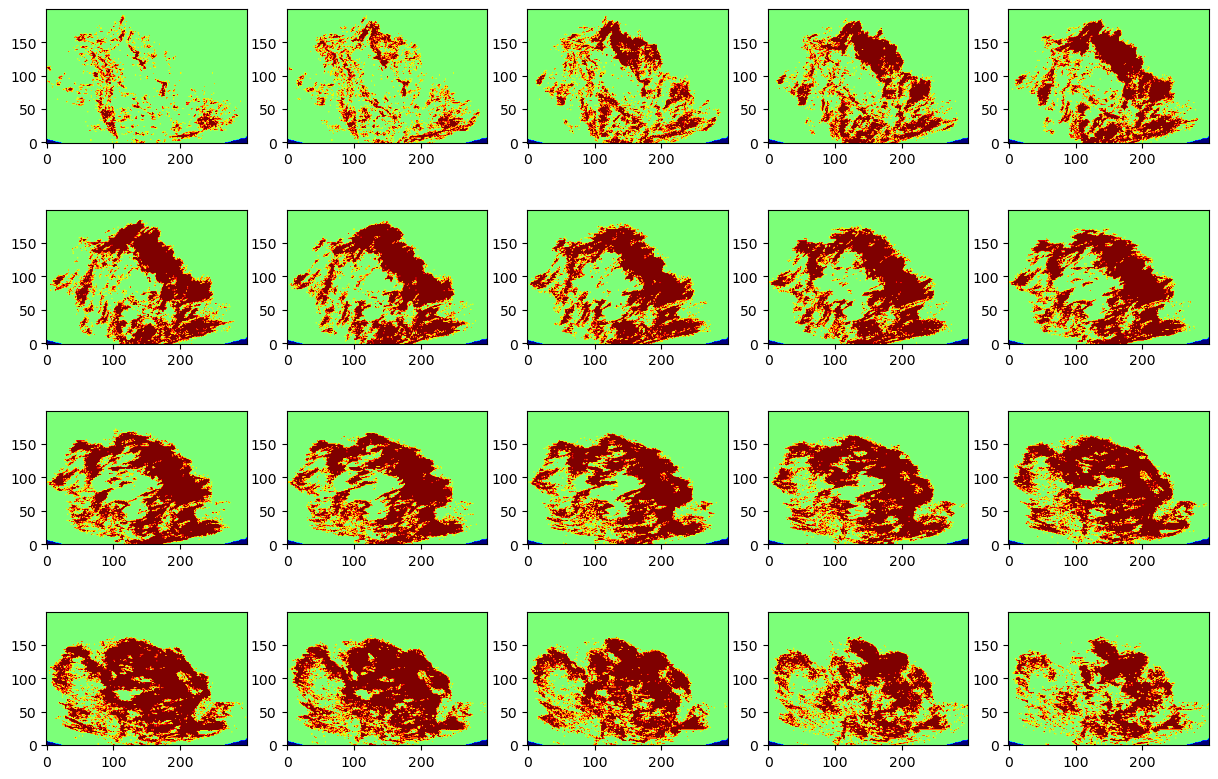

In [29]:
i_min = 0
i_max = min(200, slab_or.shape[0])
j_min = 200
j_max = min(500, slab_or.shape[1])
k_min = 0
k_max = slab_or.shape[2]

slab = slab_or[i_min:i_max, j_min:j_max, k_min:k_max].copy()

fig, axs = plt.subplots(ncols=5, nrows=4, figsize=(15, 10))
for i in range(20):
    axs.flat[i].imshow(slab[..., i], cmap="jet", origin='lower')
plt.show()

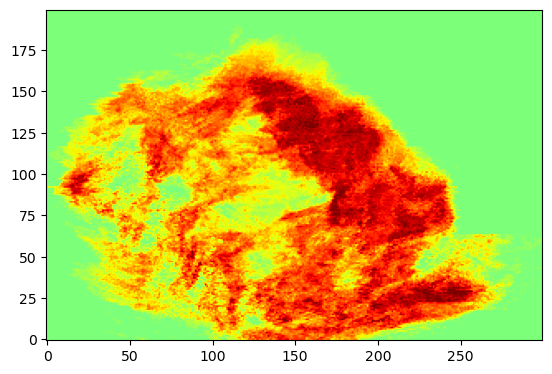

In [31]:
from scipy.ndimage import gaussian_filter

slab[slab == 0] = 1
slab_map = slab[:, :, :].sum(axis=2) / slab.shape[2]
# slab_map = gaussian_filter(slab_map, sigma=1)

plt.figure()
plt.imshow(slab_map, origin='lower', vmin=0, vmax=2, cmap='jet')
plt.show()

100%|██████████| 59004/59004 [00:33<00:00, 1776.66it/s]


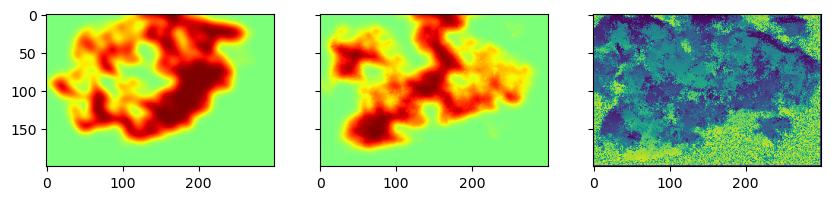

In [151]:
import bitis as bt
from scipy import ndimage


training_image = slab[:, :, slab.shape[2]//2]
training_image[training_image == 0] = 1
training_image = ndimage.gaussian_filter(training_image, 5)

max_known_pixels = 30
max_template_size = 50
min_template_size = 3
num_of_candidates = 5
min_known_pixels = 1

simulation_tex = training_image.copy()
# simulation_tex = np.ones_like(training_image)
simulation_tex[1:-1, 1:-1] = 0


simulation = bt.Simulation()
simulation.path_builder = bt.RandomSimulationPathBuilder(simulation_tex)
simulation.template_builder = bt.AdaptiveTemplateBuilder(simulation_tex,
                                                         max_known_pixels,
                                                         max_template_size,
                                                         min_template_size)
simulation.template_matching = bt.ContinuousVariableMatching(training_image,
                                                             num_of_candidates,
                                                             min_known_pixels)
simulated_tex = simulation.run()
joint_simulated_image = simulated_tex.copy()
joint_training_image = training_image.copy()

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(joint_training_image, vmin=0, vmax=2, cmap="jet")
ax[1].imshow(joint_simulated_image, vmin=0, vmax=2, cmap="jet")
ax[2].imshow(simulation._index_map, cmap="viridis")
plt.show()

In [152]:
sim_slab = np.zeros_like(slab)

for i in range(slab.shape[2]):
    training_image = slab[:, :, i].copy()
    # joint_training_image = ndimage.gaussian_filter(slab[:, :, i], 5)
    # joint_simulated_image = ndimage.gaussian_filter(sim_slab[:, :, i], 5)

    simulation_tex = np.ones_like(training_image)
    simulation_tex[1:-1, 1:-1] = 0

    multi_var_simulation = bt.Simulation()
    multi_var_simulation.path_builder = bt.MultivariateSimulationPathBuilder(simulation_tex)
    multi_var_simulation.template_builder = bt.AdaptiveTemplateBuilder(simulation_tex,
                                                         max_known_pixels,
                                                         max_template_size,
                                                         min_template_size)
    multi_var_simulation.template_matching = bt.MultivariateVariableMatching(training_image,
                                                               joint_training_image,
                                                               joint_simulated_image,
                                                               num_of_candidates,
                                                               min_known_pixels)

    simulated_tex = multi_var_simulation.run()
    sim_slab[:, :, i] = simulated_tex.copy()

100%|██████████| 59004/59004 [00:28<00:00, 2065.66it/s]


(200, 300, 20)


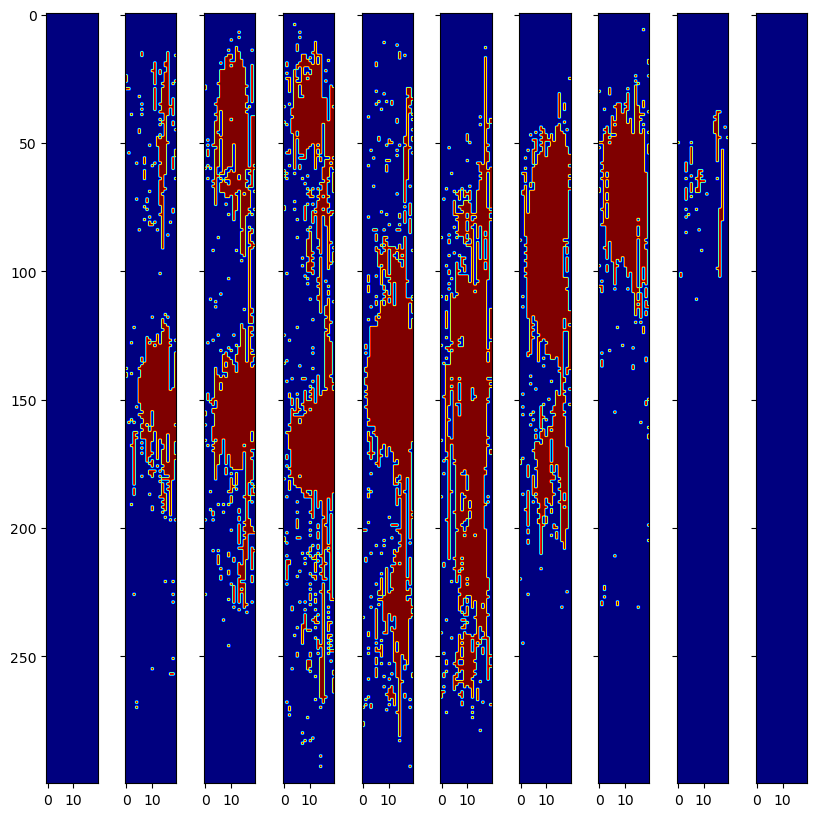

In [153]:
from scipy import ndimage

mesh = ndimage.binary_fill_holes(sim_slab == 2)
# mesh = sim_slab

print(mesh.shape)

fig, axs = plt.subplots(ncols=10, figsize=(10, 10), sharex=True, sharey=True)
idx = np.linspace(0, mesh.shape[0] - 1, 10).astype(int)
for i, ax in enumerate(axs):
    sl = mesh[idx[i]]
    # sl = np.roll(sl, 150, axis=0)
    ax.imshow(sl, cmap='jet')
    # ax.set_ylim([0, y_max])
plt.show()

np.save('slab.npy', mesh.astype(np.uint8))

(200, 300, 20)


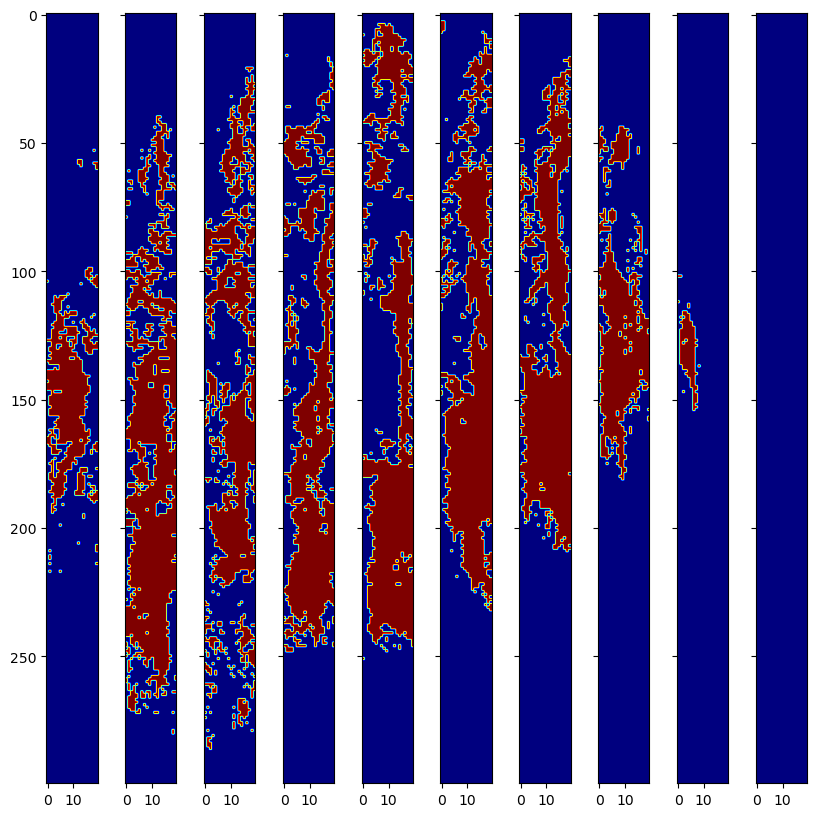

In [128]:
print(slab.shape)

fig, axs = plt.subplots(ncols=10, figsize=(10, 10), sharex=True, sharey=True)
idx = np.linspace(0, slab.shape[0] - 1, 10).astype(int)
for i, ax in enumerate(axs):
    sl = slab[idx[i]]
    # sl = np.roll(sl, 150, axis=0)
    ax.imshow(sl, cmap='jet')
    # ax.set_ylim([0, y_max])
plt.show()

np.save('slab.npy', slab.astype(np.uint8))

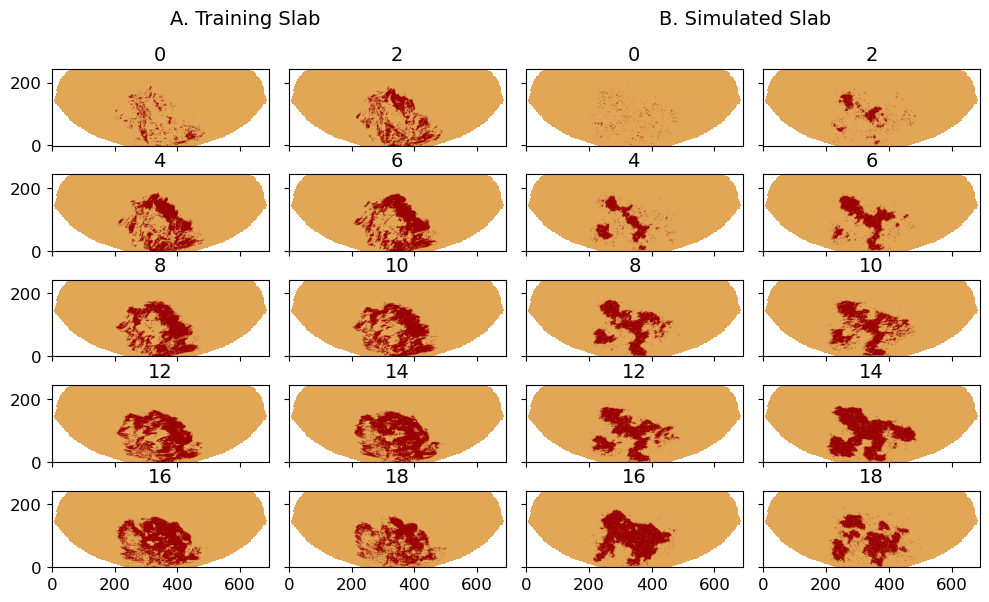

In [156]:
from matplotlib import colors as mcolors

tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, 'white'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

full_sim_slab = slab_or.copy()
full_sim_slab[i_min:i_max, j_min:j_max, k_min:k_max] = sim_slab.copy()
full_sim_slab[slab_or == 0] = 0

left_inds = [0, 1, 4, 5, 8, 9, 12, 13, 16, 17]
right_inds = [2, 3, 6, 7, 10, 11, 14, 15, 18, 19]

fig, axs = plt.subplots(nrows=5, ncols=4, figsize=(10, 6), sharex=True, sharey=True)

for i, (l_ind, r_ind) in enumerate(zip(left_inds, right_inds)):
    ax = axs.flat[l_ind]
    im = slab_or[:, :, 2 * i].copy()
    im = np.ma.array(im, mask=im == 0)
    ax.imshow(im, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
    ax.set_title(2 * i, fontsize=14)

    ax = axs.flat[r_ind]
    im = full_sim_slab[:, :, 2 * i].copy()
    im = np.ma.array(im, mask=im == 0)
    ax.imshow(im, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
    ax.set_title(2 * i, fontsize=14)

for ax in axs.flat:
    ax.set_anchor('NW')
    ax.tick_params(axis='both', which='major', labelsize=12)

fig.text(0.25, 0.95, "A. Training Slab", ha="center", va="center",
         fontsize=14)
fig.text(0.75, 0.95, "B. Simulated Slab", ha="center", va="center",
         fontsize=14)

for ax in axs.flat:
    ax.set_anchor('NW')
    ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for subtitles
plt.show()
    

In [157]:
fig.savefig("/Users/arstanbek/Projects/fibrosis/BiTis/Tutorials/figure8.png",
            dpi=300, bbox_inches='tight')


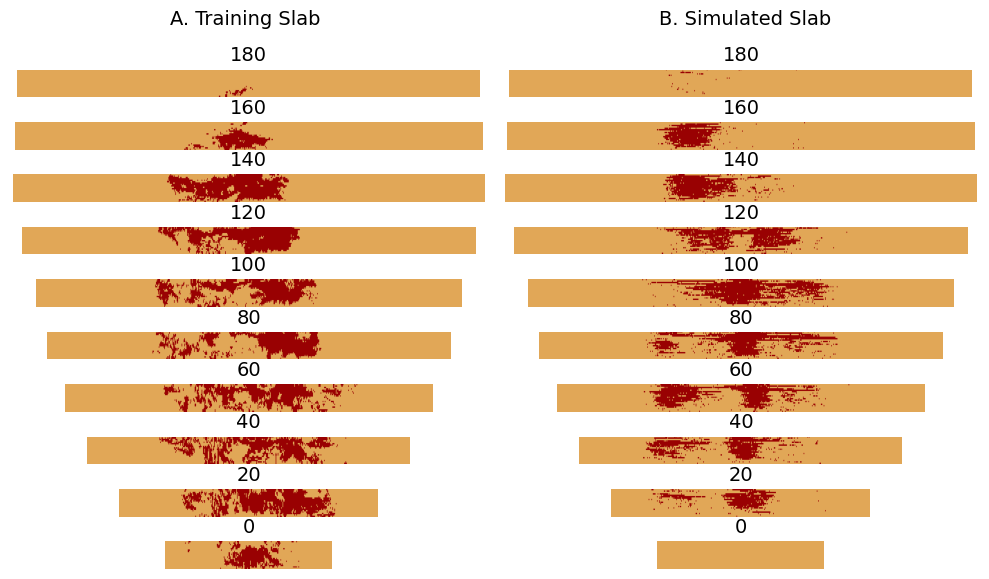

In [158]:
from matplotlib import colors as mcolors

tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, 'white'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

full_sim_slab = slab_or.copy()
full_sim_slab[i_min:i_max, j_min:j_max, k_min:k_max] = sim_slab.copy()
full_sim_slab[slab_or == 0] = 0

n_pairs = 10  # how many pairs you want
left_inds = np.arange(n_pairs) * 2
right_inds = left_inds + 1
inds = np.arange(180, -1, -20)

fig, axs = plt.subplots(nrows=n_pairs, ncols=2, figsize=(10, 6), sharex=True, sharey=True)

for i, (l_ind, r_ind) in enumerate(zip(left_inds, right_inds)):
    ax = axs.flat[l_ind]
    im = slab_or[inds[i]].copy().T
    im = np.ma.array(im, mask=im == 0)
    ax.imshow(im, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
    ax.set_title(inds[i], fontsize=14)

    ax = axs.flat[r_ind]
    im = full_sim_slab[inds[i]].copy().T
    im = np.ma.array(im, mask=im == 0)
    ax.imshow(im, cmap=tex_cmap, origin='lower', vmin=0, vmax=2)
    ax.set_title(inds[i], fontsize=14)

for ax in axs.flat:
    ax.set_aspect(2)
    ax.set_anchor('NW')
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.axis('off')

fig.text(0.25, 0.95, "A. Training Slab", ha="center", va="center",
         fontsize=14)
fig.text(0.75, 0.95, "B. Simulated Slab", ha="center", va="center",
         fontsize=14)

for ax in axs.flat:
    ax.set_anchor('NW')
    ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave space for subtitles
plt.show()
    

In [159]:
fig.savefig("/Users/arstanbek/Projects/fibrosis/BiTis/Tutorials/figure9.png",
            dpi=300, bbox_inches='tight')